# Benchmark 复刻:Lim, Zohren & Roberts (2019)

复刻论文 *Enhancing Time Series Momentum Strategies Using Deep Neural Networks* 中的三个参考策略(Section III-A、V-B),并按 Section VI 加入交易成本。

| Benchmark | 信号 $X_t$ | 出处 |
|---|---|---|
| Long Only | $1$ | 带波动率缩放的纯多头 |
| Sgn(Returns) | $\mathrm{sgn}(r_{t-252,t})$ | Moskowitz et al. 2012,式 (2)(3) |
| MACD | $\frac{1}{3}\sum_k \phi(Y_t(S_k,L_k))$ | Baz et al. 2015,式 (4)–(8) |

组合收益(式 1):
$$r^{TSMOM}_{t,t+1}=\frac{1}{N_t}\sum_{i=1}^{N_t}X^{(i)}_t\,\frac{\sigma_{tgt}}{\sigma^{(i)}_t}\,r^{(i)}_{t,t+1}$$

**运行方式**:从上到下依次运行即可。所有可调参数都在第 1 节。

## 1. 参数设置

In [1]:
# ---- 项目路径：向上找到项目根目录，把 src/ 加入 import 路径 ----
import sys
from pathlib import Path
_root = Path.cwd().resolve()
while not (_root / "src" / "paths.py").exists():
    if _root == _root.parent:
        raise FileNotFoundError("找不到项目根目录（含 src/paths.py 的文件夹）")
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
from paths import DATA_RAW, DATA_CACHE, RES_BENCH_REPLICATION
from universe import UNIVERSE, COST_SHEET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 路径(统一定义在 src/paths.py) ----------
DATA_DIR   = DATA_RAW
PRICE_FILE = DATA_DIR / "ohlcv_data_adjusted.xlsx"        # 每个 sheet 一个标的
COST_FILE  = DATA_DIR / "trading_cost_50_etfs_1.xlsx"     # sheet「Cost(高流动性20支)」: Ticker, 单边成本 c_i (bp)
OUT_DIR    = RES_BENCH_REPLICATION
CACHE      = DATA_CACHE / "prices_cache.pkl"                # 首次读 Excel 较慢,之后读缓存

# ---------- 论文参数 ----------
SIGMA_TGT  = 0.15                       # 年化目标波动率
VOL_SPAN   = 60                         # 事前波动率的 EWM span
MOM_LOOKBK = 252                        # Sgn(Returns) 的回看窗口
MACD_PAIRS = [(8, 24), (16, 48), (32, 96)]
MACD_AVG   = True                       # True: 三组取平均(X 落在 [-1,1]); False: 按式 (8) 直接求和
ANN        = 252

# ---------- 你需要决定的两项 ----------
START_DATE = "2026-06-01"               # 回测(评估)起点; 信号仍用全部历史计算。None = 最早可用日期
END_DATE   = None
EXCLUDE    = []                         # 在资产池(src/universe.py)基础上再剔除的标的

# ---------- 镜像 ETF 对: 同一时刻每对最多持有一只 ----------
# 每对写成 (正向 ETF, 反向 ETF),底层资产相同、方向相反
PAIRS = [("TMF", "TMV"), ("UBT", "TBT"), ("TYD", "TYO"), ("UST", "PST"), ("UUP", "UDN")]
PAIRS = [(a, b) for a, b in PAIRS if a in UNIVERSE and b in UNIVERSE]   # 只保留两只都在资产池里的对(当前资产池下为空)
PAIR_RULE = "strongest"                 # "strongest": 保留 |X| 较大的一只,相同则保留正向 ETF(可多可空,最接近论文)
                                        # "long_side": 只做多信号为正的那只,用反向 ETF 代替做空;两只都不为正则都不持有
                                        # None:        不处理,两只可同时持有

# ---------- 组合层面的二次缩放(Exhibit 3) ----------
RESCALE_MODE = "constant"               # "constant": 全样本乘一个常数使波动率=15%(不改变 Sharpe)
                                        # "ewm":      用滞后一天的 60 日 EWM 组合波动率逐日缩放(无前视)

## 2. 读取数据

In [2]:
if CACHE.exists() and CACHE.stat().st_mtime > PRICE_FILE.stat().st_mtime:
    raw = pd.read_pickle(CACHE)
else:
    raw = pd.read_excel(PRICE_FILE, sheet_name=None)       # 约 1 分钟
    pd.to_pickle(raw, CACHE)

close = {}
for tkr, df in raw.items():
    if tkr in EXCLUDE or tkr not in UNIVERSE:
        continue
    s = (df.assign(Date=pd.to_datetime(df["Date"]))
           .dropna(subset=["Close"]).drop_duplicates("Date").set_index("Date")["Close"].sort_index())
    close[tkr] = s[s > 0]

missing = [t for t in UNIVERSE if t not in raw]
assert not missing, f"价格文件中缺少资产池标的: {missing}"

cost_bp = pd.read_excel(COST_FILE, sheet_name=COST_SHEET).set_index("Ticker").iloc[:, 0].astype(float)
cost = (cost_bp / 1e4).reindex(list(close))                # bp -> 小数
assert cost.notna().all(), f"缺少成本的标的: {cost[cost.isna()].index.tolist()}"

info = pd.DataFrame({"start": {k: v.index[0].date() for k, v in close.items()},
                     "end":   {k: v.index[-1].date() for k, v in close.items()},
                     "n_obs": {k: len(v) for k, v in close.items()},
                     "cost_bp": cost_bp.reindex(list(close))})
print(f"标的数: {len(close)}")
info

标的数: 50


,start,end,n_obs,cost_bp
SPY,2001-01-02,2026-09-03,6456,0.5
QQQ,2001-01-02,2026-09-03,6456,1.0
GLD,2004-11-18,2026-09-03,5482,0.5
SLV,2006-04-28,2026-09-03,5120,1.0
DBC,2006-02-06,2026-09-03,5177,5.0
UUP,2007-03-01,2026-09-03,4910,5.0
XLK,2001-01-02,2026-09-03,6456,0.5
PSCT,2010-04-07,2026-09-03,4129,15.0
XLV,2001-01-02,2026-09-03,6456,0.5
PSCH,2010-04-07,2026-09-03,4129,15.0


## 3. 信号与仓位

所有计算都在**每个标的自己的交易日历**上完成(港股、欧股、新加坡的交易日与美股不同),最后再对齐。

- 日收益 $r_t = P_t/P_{t-1}-1$
- 事前波动率 $\sigma_t$:日收益的 EWM 标准差(span=60),年化
- MACD:$m(S)$ 是半衰期 $HL=\ln 0.5/\ln(1-1/S)$ 的指数均线;$q_t=\dfrac{m(S)-m(L)}{\mathrm{std}(p_{t-63:t})}$,$Y_t=\dfrac{q_t}{\mathrm{std}(q_{t-252:t})}$,$\phi(y)=\dfrac{y\,e^{-y^2/4}}{0.89}$
- 仓位 $w_t = X_t\,\sigma_{tgt}/\sigma_t$,**在 $t$ 日收盘确定,赚取 $t+1$ 日的收益**(代码中用 `shift(1)`,避免前视)
- **镜像 ETF 对**(如 TMF/TMV):每天按 $t$ 日的信号在每对中最多选一只持有,另一只仓位为空且不计入 $N_t$;换仓时两边的交易都计成本

In [3]:
def phi(y):
    return y * np.exp(-y**2 / 4) / 0.89

def macd_signal(p, S, L):
    hl = lambda n: np.log(0.5) / np.log(1 - 1 / n)
    macd = p.ewm(halflife=hl(S)).mean() - p.ewm(halflife=hl(L)).mean()
    q = macd / p.rolling(63).std()
    return q / q.rolling(252).std()

def signals(p):
    # 返回单个标的的日收益、年化事前波动率、三个 benchmark 的信号 X
    r   = p.pct_change()
    vol = r.ewm(span=VOL_SPAN, min_periods=VOL_SPAN).std() * np.sqrt(ANN)
    X = pd.DataFrame(index=p.index)
    X["Long Only"]    = 1.0
    X["Sgn(Returns)"] = np.sign(p / p.shift(MOM_LOOKBK) - 1)
    m = sum(phi(macd_signal(p, S, L)) for S, L in MACD_PAIRS)
    X["MACD"] = m / len(MACD_PAIRS) if MACD_AVG else m
    # 三个信号都可用之后才纳入该标的,保证三个 benchmark 的样本一致
    valid = X.notna().all(axis=1) & vol.notna()
    return r, vol, X.where(valid)

STRATS = ["Long Only", "Sgn(Returns)", "MACD"]
R, V, SIG = {}, {}, {s: {} for s in STRATS}
for tkr, p in close.items():
    R[tkr], V[tkr], X = signals(p)
    for s in STRATS:
        SIG[s][tkr] = X[s]

# 对齐到统一日历: 本地休市日收益记 0,信号和波动率沿用上一交易日的值
R = pd.DataFrame(R).sort_index()
live = R.notna().cummax() & R[::-1].notna().cummax()[::-1]          # 上市之后、数据结束之前
R = R.fillna(0).where(live)
V = pd.DataFrame(V).reindex(R.index).ffill().where(live)

def apply_pairs(X):
    # 每对镜像 ETF 每天最多保留一只,被放弃的一只设为 NaN(不持有、不计入 N_t)
    X = X.copy()
    for a, b in PAIRS:
        if PAIR_RULE is None or a not in X or b not in X:
            continue
        xa, xb = X[a], X[b]
        both = xa.notna() & xb.notna()
        if PAIR_RULE == "strongest":
            keep_a = xa.abs() >= xb.abs()
            X.loc[both & ~keep_a, a] = np.nan
            X.loc[both & keep_a,  b] = np.nan
        elif PAIR_RULE == "long_side":
            keep_a = (xa > 0) & (xa >= xb.fillna(-np.inf))
            keep_b = (xb > 0) & ~keep_a
            X[a] = xa.where(keep_a)
            X[b] = xb.where(keep_b)
    return X

gross, turn, pos = {}, {}, {}
for s in STRATS:
    X = apply_pairs(pd.DataFrame(SIG[s]).reindex(R.index).ffill().where(live))
    W = X * SIGMA_TGT / V                                   # t 日收盘的目标仓位
    held = W.shift(1).notna()                               # t+1 日是否持有
    gross[s] = (W.shift(1) * R).where(held).loc[START_DATE:END_DATE]      # t+1 日实现的收益
    dW = (W.fillna(0) - W.shift(1).fillna(0)).abs()         # 式 (34) 的换手,含建仓/平仓/对内换仓
    # 成本记在 t+1 日(式 35),此处尚未乘 c; 平仓成本记在平仓后的第一天
    turn[s]  = dW.shift(1).where(held | (dW.shift(1) > 0)).loc[START_DATE:END_DATE]
    pos[s]   = W.loc[START_DATE:END_DATE]

n_assets = gross["MACD"].notna().sum(axis=1)
print("回测区间:", gross["MACD"].dropna(how="all").index[0].date(), "→", gross["MACD"].index[-1].date())

回测区间: 2026-06-01 → 2026-09-03


## 4. 组合收益

- **Gross**:式 (1),不含成本(对应论文 Exhibit 2/3)
- **Net**:式 (35),$\tilde r_{t,t+1}=\frac{1}{N_t}\sum_i\left(w^{(i)}_t r^{(i)}_{t,t+1}-c_i\,|w^{(i)}_t-w^{(i)}_{t-1}|\right)$,其中 $c_i$ 用你成本表里每个标的自己的单边成本

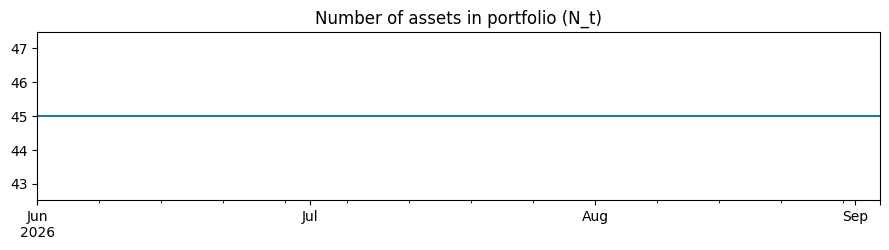

In [4]:
def portfolio(strategy, c=None):
    # c=None: 不含成本; c=Series: 各标的成本; c=float: 统一成本(小数)
    g = gross[strategy]
    n = g.notna().sum(axis=1)                              # N_t: 当日持有的标的数
    total = g.sum(axis=1)
    if c is not None:
        total = total - (turn[strategy] * c).sum(axis=1)
    return (total / n)[n > 0]                              # 对当日持有的 N_t 个标的等权平均

def rescale(r, mode=RESCALE_MODE):
    if mode == "constant":
        return r * SIGMA_TGT / (r.std() * np.sqrt(ANN))
    v = (r.ewm(span=VOL_SPAN, min_periods=VOL_SPAN).std() * np.sqrt(ANN)).shift(1)
    return (r * SIGMA_TGT / v).dropna()

port_gross = pd.DataFrame({s: portfolio(s) for s in STRATS}).dropna()
port_net   = pd.DataFrame({s: portfolio(s, cost) for s in STRATS}).dropna()

ax = n_assets.plot(figsize=(9, 2.6), title="Number of assets in portfolio (N_t)")
ax.set_xlabel(""); plt.tight_layout(); plt.show()

## 5. 绩效指标(对应论文 Section V-B 的九项指标)

In [5]:
def metrics(r):
    r = r.dropna()
    mu, vol = r.mean() * ANN, r.std() * np.sqrt(ANN)
    dd  = np.sqrt((np.minimum(r, 0) ** 2).mean()) * np.sqrt(ANN)     # 下行偏差
    cum = (1 + r).cumprod()
    mdd = (1 - cum / cum.cummax()).max()
    return pd.Series({"E[Return]": mu, "Vol.": vol, "Downside Dev.": dd, "MDD": mdd,
                      "Sharpe": mu / vol, "Sortino": mu / dd, "Calmar": mu / mdd,
                      "% +ve Returns": (r > 0).mean(),
                      "Ave.P / Ave.L": r[r > 0].mean() / -r[r < 0].mean()})

def table(df):
    return df.apply(metrics).T.round(3)

exhibit2 = table(port_gross)
exhibit3 = table(port_gross.apply(rescale))
print("Exhibit 2 — Raw signal outputs (gross)");            display(exhibit2)
print("Exhibit 3 — Rescaled to 15% target vol (gross)");    display(exhibit3)

Exhibit 2 — Raw signal outputs (gross)


,E[Return],Vol.,Downside Dev.,MDD,Sharpe,Sortino,Calmar,% +ve Returns,Ave.P / Ave.L
Long Only,0.079,0.067,0.046,0.016,1.185,1.737,4.927,0.551,0.983
Sgn(Returns),0.038,0.053,0.039,0.016,0.730,0.993,2.359,0.565,0.873
MACD,0.031,0.025,0.018,0.006,1.224,1.737,4.771,0.551,0.999


Exhibit 3 — Rescaled to 15% target vol (gross)


,E[Return],Vol.,Downside Dev.,MDD,Sharpe,Sortino,Calmar,% +ve Returns,Ave.P / Ave.L
Long Only,0.178,0.15,0.102,0.036,1.185,1.737,4.964,0.551,0.983
Sgn(Returns),0.109,0.15,0.110,0.046,0.730,0.993,2.371,0.565,0.873
MACD,0.184,0.15,0.106,0.038,1.224,1.737,4.775,0.551,0.999


## 6. 累计收益(对应 Exhibit 4)

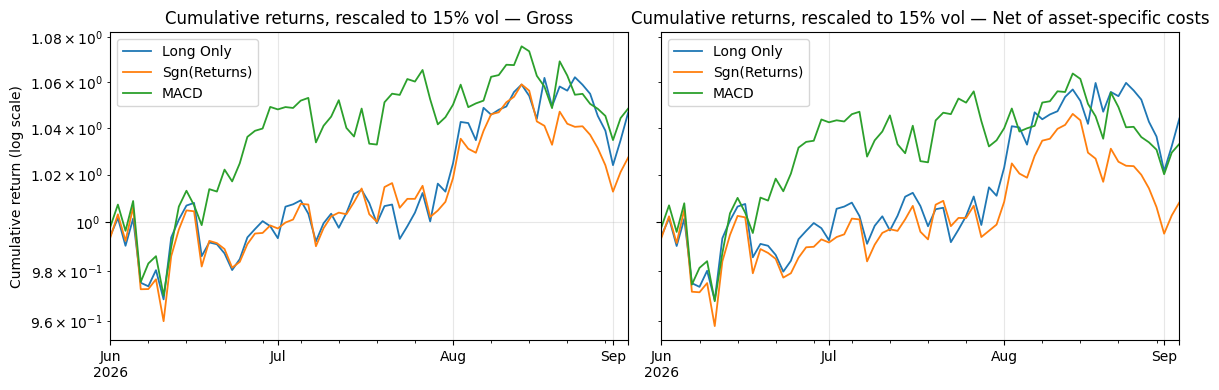

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, ttl in [(axes[0], port_gross.apply(rescale), "Gross"),
                    (axes[1], port_net.apply(rescale),   "Net of asset-specific costs")]:
    (1 + df).cumprod().plot(ax=ax, logy=True, lw=1.3)
    ax.set_title(f"Cumulative returns, rescaled to 15% vol — {ttl}"); ax.set_xlabel(""); ax.grid(alpha=.3)
axes[0].set_ylabel("Cumulative return (log scale)")
plt.tight_layout(); plt.savefig(OUT_DIR / "cumulative_returns.png", dpi=150); plt.show()

## 7. 单个标的层面(对应 Exhibit 5)

检查点:Long Only 和 Sgn(Returns) 的各标的年化波动率应集中在 15% 附近;MACD 因为 $|X|<1$ 会更低(论文中约 10%)。

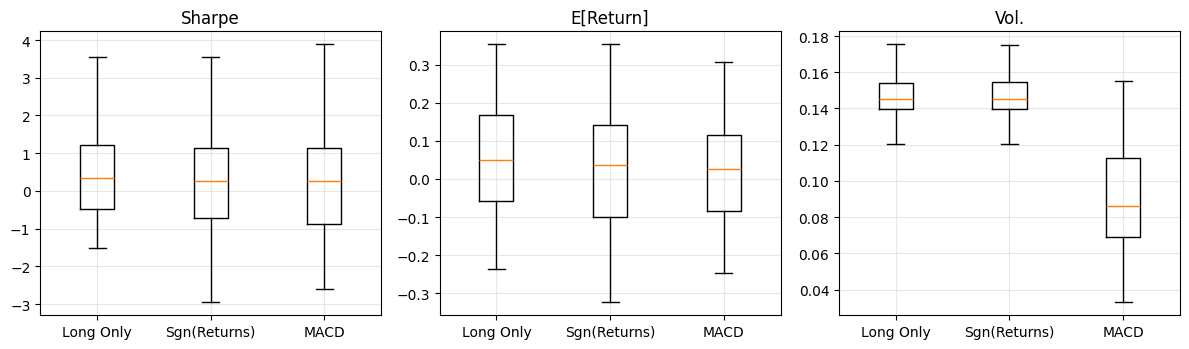

每对镜像 ETF 同时持有的天数(应全为 0): {'Long Only': 0, 'Sgn(Returns)': 0, 'MACD': 0}
镜像 ETF 各自被持有的天数:


,TMF,TMV,UBT,TBT,TYD,TYO,UST,PST,UUP,UDN
Long Only,69,0,69,0,69,0,69,0,69,0
Sgn(Returns),69,0,69,0,69,0,69,0,69,0
MACD,33,36,44,25,54,15,17,52,60,9


Long Only                  Sgn(Returns)                    MACD  \
           Sharpe E[Return]   Vol.       Sharpe E[Return]   Vol. Sharpe   
SPY         0.527     0.078  0.148        0.527     0.078  0.148 -0.038   
QQQ        -0.529    -0.087  0.164       -0.529    -0.087  0.164 -1.159   
GLD        -0.078    -0.012  0.154       -0.078    -0.012  0.154 -1.248   
SLV        -0.466    -0.058  0.125       -0.466    -0.058  0.125 -0.854   
DBC         1.436     0.210  0.146        1.436     0.210  0.146  1.770   
UUP         0.765     0.116  0.152        0.765     0.116  0.152  0.930   
XLK        -0.297    -0.049  0.165       -0.297    -0.049  0.165 -0.860   
PSCT       -0.720    -0.113  0.157       -0.720    -0.113  0.157 -0.686   
XLV         3.160     0.517  0.164        3.160     0.517  0.164  2.720   
PSCH        4.152     0.560  0.135        4.152     0.560  0.135  3.889   
XLF         3.538     0.515  0.145        3.538     0.515  0.145  2.931   
PSCF        2.057     0.289  0.140        2.057     0.289  0.140  2.192   
XLE         2.525     0.354  0.140        2.525     0.354  0.140  2.252   
PSCE        1.133     0.174  0.154        1.133     0.174  0.154  0.571   
XLY        -0.796    -0.124  0.156       -2.097    -0.324  0.155 -5.090   
PSCD        1.215     0.163  0.134        1.215     0.163  0.134  0.923   
XLP         0.907     0.141  0.155        0.907     0.141  0.155  0.145   
PSCC        2.074     0.322  0.155        0.072     0.011  0.156  0.864   
XLI        -0.030    -0.004  0.143       -0.030    -0.004  0.143  0.216   
PSCI       -0.147    -0.021  0.141       -0.147    -0.021  0.141  0.781   
XLB         0.612     0.091  0.148        0.612     0.091  0.148 -0.128   
PSCM       -0.722    -0.101  0.140       -0.722    -0.101  0.140 -1.336   
XLU        -0.720    -0.104  0.144       -0.720    -0.104  0.144 -2.593   
PSCU       -0.272    -0.038  0.141       -0.272    -0.038  0.141 -1.285   
XLRE        0.335     0.050  0.150        0.335     0.050  0.150  0.131   
XLC        -0.724    -0.127  0.175       -1.445    -0.253  0.175 -1.919   
UBT        -1.146    -0.177  0.154        0.405     0.063  0.155  0.262   
UST        -1.174    -0.166  0.142       -0.632    -0.090  0.142    NaN   
TMF        -1.375    -0.210  0.153        0.670     0.103  0.153  1.704   
TYD        -1.503    -0.217  0.145        0.808     0.117  0.145 -0.412   
FXE         0.111     0.016  0.146       -3.788    -0.539  0.142 -1.726   
FXY         1.022     0.199  0.194       -1.022    -0.199  0.194 -0.890   
FXB         0.789     0.105  0.133       -0.886    -0.118  0.133 -1.149   
FXC        -0.146    -0.024  0.166       -1.278    -0.211  0.165 -1.385   
FXA         0.669     0.089  0.133        0.669     0.089  0.133  0.506   
FXF        -1.435    -0.238  0.166       -2.955    -0.483  0.164 -0.871   
DIA         1.433     0.209  0.146        1.433     0.209  0.146  1.495   
MDY         0.369     0.050  0.135        0.369     0.050  0.135  0.774   
FEZ         1.239     0.141  0.114        1.239     0.141  0.114  1.273   
IWM         0.274     0.036  0.131        0.274     0.036  0.131  0.504   
2800.HK     0.315     0.045  0.143       -1.115    -0.159  0.143 -1.988   
CAC.PA      0.089     0.011  0.121        0.089     0.011  0.121  1.008   
EWG         0.878     0.107  0.121       -1.985    -0.240  0.121 -0.387   
ISF.L       1.435     0.167  0.116        1.435     0.167  0.116  0.836   
ES3.SI      4.763     0.679  0.143        4.763     0.679  0.143  4.458   
TBT           NaN       NaN    NaN          NaN       NaN    NaN  1.408   
PST           NaN       NaN    NaN          NaN       NaN    NaN  2.151   
TMV           NaN       NaN    NaN          NaN       NaN    NaN  0.660   

                          
        E[Return]   Vol.  
SPY        -0.004  0.111  
QQQ        -0.151  0.130  
GLD        -0.078  0.063  
SLV        -0.047  0.055  
DBC         0.122  0.069  
UUP         0.126  0.135  
XLK        -0.112  0.131  
PSCT       -0.

In [7]:
MIN_OBS = 20                                               # 持有天数太少的标的不统计
per_asset = {s: gross[s].loc[:, gross[s].notna().sum() >= MIN_OBS]
                .apply(lambda x: metrics(x)[["Sharpe", "E[Return]", "Vol."]]).T for s in STRATS}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, m in zip(axes, ["Sharpe", "E[Return]", "Vol."]):
    ax.boxplot([per_asset[s][m].dropna() for s in STRATS], showfliers=False)
    ax.set_xticks(range(1, len(STRATS) + 1), STRATS)
    ax.set_title(m); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT_DIR / "per_asset_boxplots.png", dpi=150); plt.show()

if PAIRS and PAIR_RULE:
    chk = {s: max(int((pos[s][a].notna() & pos[s][b].notna()).sum()) for a, b in PAIRS if a in pos[s] and b in pos[s]) for s in STRATS}
    print("每对镜像 ETF 同时持有的天数(应全为 0):", chk)
    days = pd.DataFrame({s: pos[s][[t for p in PAIRS for t in p if t in pos[s]]].notna().sum() for s in STRATS})
    print("镜像 ETF 各自被持有的天数:"); display(days.T)
pd.concat(per_asset, axis=1).round(3)

## 8. 换手与交易成本(对应 Section VI、Exhibit 6–7)

- 平均日换手 $\zeta_t=\sigma_{tgt}\left|\frac{X_t}{\sigma_t}-\frac{X_{t-1}}{\sigma_{t-1}}\right|$
- 成本后 Sharpe:分别用你成本表里的 $c_i$,以及论文的统一成本 $c\in\{1,\dots,5,10\}$ bp

In [8]:
turnover = pd.DataFrame({s: turn[s].mean() for s in STRATS})
print("平均日换手(各标的的中位数):"); display(turnover.median().round(4).to_frame("median daily turnover").T)

rows = {"No cost": port_gross.apply(lambda r: metrics(r)["Sharpe"]),
        "Asset-specific c_i": port_net.apply(lambda r: metrics(r)["Sharpe"])}
for bp in [1, 2, 3, 4, 5, 10]:
    rows[f"Uniform {bp}bp"] = pd.Series({s: metrics(portfolio(s, bp / 1e4).loc[port_gross.index])["Sharpe"] for s in STRATS})
cost_sharpe = pd.DataFrame(rows).T.round(3)
print("不同成本假设下的 Sharpe:"); display(cost_sharpe)

exhibit3_net = table(port_net.apply(rescale))
print("Rescaled to 15% vol — net of asset-specific costs"); display(exhibit3_net)

平均日换手(各标的的中位数):


,Long Only,Sgn(Returns),MACD
median daily turnover,0.0129,0.0157,0.0236


不同成本假设下的 Sharpe:


,Long Only,Sgn(Returns),MACD
No cost,1.185,0.730,1.224
Asset-specific c_i,1.123,0.276,0.867
Uniform 1bp,1.178,0.689,1.187
Uniform 2bp,1.171,0.649,1.151
Uniform 3bp,1.164,0.609,1.114
Uniform 4bp,1.158,0.569,1.077
Uniform 5bp,1.151,0.529,1.041
Uniform 10bp,1.117,0.327,0.857


Rescaled to 15% vol — net of asset-specific costs


,E[Return],Vol.,Downside Dev.,MDD,Sharpe,Sortino,Calmar,% +ve Returns,Ave.P / Ave.L
Long Only,0.168,0.15,0.103,0.036,1.123,1.641,4.685,0.551,0.974
Sgn(Returns),0.041,0.15,0.112,0.048,0.276,0.368,0.854,0.536,0.907
MACD,0.130,0.15,0.107,0.041,0.867,1.211,3.178,0.551,0.942


## 9. 保存结果

日度收益序列会在之后和 LSTM 等模型比较时用到。

In [9]:
with pd.ExcelWriter(OUT_DIR / "benchmark_results.xlsx") as xw:
    exhibit2.to_excel(xw, sheet_name="Exhibit2_raw_gross")
    exhibit3.to_excel(xw, sheet_name="Exhibit3_rescaled_gross")
    exhibit3_net.to_excel(xw, sheet_name="Rescaled_net")
    cost_sharpe.to_excel(xw, sheet_name="Sharpe_vs_cost")
    turnover.to_excel(xw, sheet_name="Turnover_by_asset")
    pd.concat(per_asset, axis=1).to_excel(xw, sheet_name="Per_asset")
port_gross.to_csv(OUT_DIR / "benchmark_daily_returns_gross.csv")
port_net.to_csv(OUT_DIR / "benchmark_daily_returns_net.csv")
print("已保存到", OUT_DIR.resolve())

已保存到 E:\subjects\研一\Financial Econometrics\Project\Benchmark\output
